In [3]:
import mne
import numpy as np
from MaskExp.data_helpers import *
from MaskExp.EEG import preprocess_eeg, preprocess_eeg_cue


In [19]:
### Check trigger times ### 
PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/"

sub = 12
# I don't want to see all the output
mne.set_log_level('error')

# load raw files
folder_name = f"sub-{sub:04d}"
sub_folder = os.path.join(PATH, "eeg_raw", folder_name)
files = os.listdir(sub_folder)

vhdrs = [x for x in files if ".vhdr" in x]
raw = []
allowed_events = get_main_events()
rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="stims")

for vhdr in vhdrs:
    vhdr_file = os.path.join(sub_folder, vhdr)
    raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

raw = mne.concatenate_raws(raw)
# make sure eye channels are marked correctly 
raw.set_channel_types({
    'VEOG1':'eog',
    'VEOG2':'eog',
    'HEOG1':'eog',
    'HEOG2':'eog'
})


raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

events, events_ids = mne.events_from_annotations(raw)
condition_keys = list(set(rename_dict.values()))


In [20]:

sfreq = raw.info['sfreq']
target_codes = [events_ids[name] for name in condition_keys if name in events_ids]

event_samples = events[:, 0]
event_ids = events[:, 2]

is_target = np.isin(event_ids, target_codes)
start_indices = np.where(event_ids == 1)[0]

intervals = []

for start_idx in start_indices:
    next_target_idx = np.where(is_target & (np.arange(len(events)) > start_idx))[0]
    if next_target_idx.size == 0:
        continue
    next_idx = next_target_idx[0]
    dt_sec = (event_samples[next_idx] - event_samples[start_idx]) / sfreq
    intervals.append({
        "start_sample": event_samples[start_idx],
        "target_sample": event_samples[next_idx],
        "target_id": event_ids[next_idx],
        "dt_sec": dt_sec,
    })

print(f"Found {len(intervals)} intervals.")
for entry in intervals[:10]:
    print(entry)


is_80 = event_ids == 80
start_indices = np.where(is_target)[0]

intervals = []

for start_idx in start_indices:
    next_80_idx = np.where(is_80 & (np.arange(len(events)) > start_idx))[0]
    if next_80_idx.size == 0:
        continue
    next_idx = next_80_idx[0]
    dt_sec = (event_samples[next_idx] - event_samples[start_idx]) / sfreq
    intervals.append({
        "start_sample": event_samples[start_idx],
        "start_id": event_ids[start_idx],
        "target_sample": event_samples[next_idx],
        "target_id": event_ids[next_idx],
        "dt_sec": dt_sec,
    })

print(f"Found {len(intervals)} intervals from target to trigger 80.")
for entry in intervals[:10]:
    print(entry)


Found 1600 intervals.
{'start_sample': 13326, 'target_sample': 14349, 'target_id': 114, 'dt_sec': 1.023}
{'start_sample': 15625, 'target_sample': 16649, 'target_id': 112, 'dt_sec': 1.024}
{'start_sample': 17941, 'target_sample': 18966, 'target_id': 122, 'dt_sec': 1.025}
{'start_sample': 20474, 'target_sample': 21499, 'target_id': 14, 'dt_sec': 1.025}
{'start_sample': 24874, 'target_sample': 25900, 'target_id': 111, 'dt_sec': 1.026}
{'start_sample': 27350, 'target_sample': 28375, 'target_id': 11, 'dt_sec': 1.025}
{'start_sample': 29685, 'target_sample': 30708, 'target_id': 24, 'dt_sec': 1.023}
{'start_sample': 34708, 'target_sample': 35733, 'target_id': 124, 'dt_sec': 1.025}
{'start_sample': 37166, 'target_sample': 38191, 'target_id': 111, 'dt_sec': 1.025}
{'start_sample': 39566, 'target_sample': 40591, 'target_id': 114, 'dt_sec': 1.025}
Found 1600 intervals from target to trigger 80.
{'start_sample': 14349, 'start_id': 114, 'target_sample': 14382, 'target_id': 80, 'dt_sec': 0.033}
{'st

<ipython-input-21-dd54acd5f4f2>:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group1_dt, group2_dt], labels=['11-14', '21-24'])


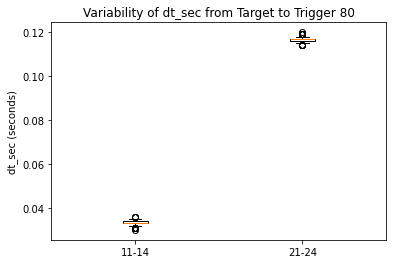

Group 11-14: 400 intervals, mean dt_sec: 0.033s, std: 0.001s
Group 21-24: 400 intervals, mean dt_sec: 0.117s, std: 0.001s


In [21]:
import matplotlib.pyplot as plt

# Group dt_sec by start_id ranges
group1_ids = [11, 12, 13, 14]
group2_ids = [21, 22, 23, 24]

group1_dt = [entry['dt_sec'] for entry in intervals if entry['start_id'] in group1_ids]
group2_dt = [entry['dt_sec'] for entry in intervals if entry['start_id'] in group2_ids]

# Plot variability (boxplot for distribution)
fig, ax = plt.subplots()
ax.boxplot([group1_dt, group2_dt], labels=['11-14', '21-24'])
ax.set_ylabel('dt_sec (seconds)')
ax.set_title('Variability of dt_sec from Target to Trigger 80')
plt.show()

print(f"Group 11-14: {len(group1_dt)} intervals, mean dt_sec: {np.mean(group1_dt):.3f}s, std: {np.std(group1_dt):.3f}s")
print(f"Group 21-24: {len(group2_dt)} intervals, mean dt_sec: {np.mean(group2_dt):.3f}s, std: {np.std(group2_dt):.3f}s")

In [4]:
# Preprocess

for sub in [14,15,16,17]:
    print(sub)
    data_val = preprocess_eeg_cue(sub=sub)
    print("---" * 20)
    preprocess_eeg(sub=sub)


14
Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching around cue (trigger 1): between -0.2s and 2.5s with a baseline = (-0.2, 0)
Total accepted trials: 1600
------------------------------------------------------------
Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching: between -0.2s and 1.0s with a baseline = (-0.2, 0)
Total accepted trials: 1600
15
Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching around cue (trigger 1): between -0.2s and 2.5s with a baseline = (-0.2, 0)
Total accepted trials: 1600
------------------------------------------------------------
Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching: between -0.2s and 1.0s with a baseline = (-0.2, 0)
Total accepted trials: 1600
16
Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching around cue (trigger 1): between -0.2s and 2.5s with a baseline = (-0.2, 0)
Total ac

In [7]:
import pandas as pd

s = pd.Series(data_val['ids'])
print(f"Total values:   {len(s)}")
print(f"Unique values:  {s.nunique()}")
print(f"\nValue counts:\n{s.value_counts()}")

Total values:   1600
Unique values:  24

Value counts:
12     100
24     100
14     100
21     100
11     100
23     100
22     100
13     100
122     70
121     70
112     70
123     70
113     70
111     70
114     70
124     70
221     30
223     30
211     30
213     30
224     30
222     30
214     30
212     30
Name: count, dtype: int64


In [ ]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import apply_sigma, estimate_sigma, mvnn

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
#CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

testsize = 0.2
group_size = 4
whitening = False
epoched_ver = "cue"
imgPerm = 1

sub_data = []
sub_data_expect = []
sub_data_unexpect = []

for sub in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]:
    all_events = get_main_events()
    if epoched_ver == "cue":
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}_cue_target.pickle")
    else:
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
    
    subject_data = load_data(subject_path)
    ids_ = subject_data["ids"]
    eeg_ = subject_data["eeg"]
    n_conditions = len(np.unique(ids_)) // 3
    _, n_sensors, n_time = eeg_.shape

    ### Store variable
    decAcc = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
    decAcc_e = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
    decAcc_u = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
    indexes = np.arange(0, n_conditions)


    # Separate trials 
    n, e, u = extract_expectations(eeg_, ids_)
    
    ### Introduce image permutation loop 
    for _ in tqdm(range(imgPerm), desc="Image permutations"):
        pstrials, pk = pseudotrials_general(n)

        # Match expected and unexpected trials  
        u_trials = u.shape[1]
        e_trials = e.shape[1]
        e = e[:, np.random.choice(np.arange(e_trials), size=u_trials, replace=False)]

        # Create e and u pseudotrials 
        pstrials_e, pk_e = pseudotrials_general(e)
        pstrials_u, pk_u = pseudotrials_general(u)

        # Cross-validation params
        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        _, n_pstrials_e, _, _ = pstrials_e.shape
        
        n_test = int(n_pstrials * testsize)
        n_test_e = int(n_pstrials_e * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)
        ps_ixs_e = np.arange(n_pstrials_e)

        ### Cross-validation loop
        for cv in tqdm(range(cvs), desc="Cross-Validation", leave=False):
            
            test_ix = np.arange(n_test) + (cv * n_test)
            test_ix_e = np.arange(n_test_e) + (cv * n_test_e)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test = pstrials[:, test_ix, :, :]
            ps_test_e = pstrials_e[:, test_ix, :, :]
            ps_test_u = pstrials_u[:, test_ix, :, :]


            ### Pairwise loop
            for start in range(0, n_conditions, group_size):
                group = indexes[start:start + group_size]
                
                ### MVNN according to Guggenmos 
                if whitening:
                    sigma_inv = estimate_sigma(ps_train[group])
                    ps_test_e_w = apply_sigma(ps_test_e[group], sigma_inv)
                    ps_test_u_w = apply_sigma(ps_test_u[group], sigma_inv)
                    
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                    
                else:
                    ps_train_w, ps_test_w = ps_train[group], ps_test[group]
                    ps_test_e_w, ps_test_u_w = ps_test_e[group], ps_test_u[group]
                
                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:                
                        for t in range(n_time):
                            ### Neutral train and tests ###
                            train_x = np.array((ps_train_w[cA % group_size, :, :, t], ps_train_w[cB % group_size, :, :, t]))
                            train_x = np.reshape(train_x, (len(train_ix) * 2, n_sensors))

                            test_x = np.array((ps_test_w[cA % group_size], ps_test_w[cB % group_size]))
                            test_x = np.reshape(test_x, (len(test_ix) * 2, n_sensors, n_time))

                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))
                            test_y = np.array([1] * len(test_ix) + [2] * len(test_ix))

                            ### Expected tests ###
                            expected_test_x = np.array((ps_test_e_w[cA % group_size], ps_test_e_w[cB % group_size]))
                            expected_test_x = np.reshape(expected_test_x, (len(test_ix_e) * 2, n_sensors, n_time))
                            expected_test_y = np.array([1] * len(test_ix_e) + [2] * len(test_ix_e))

                            ### Unexpected_tests ###
                            unexpected_test_x = np.array((ps_test_u_w[cA % group_size], ps_test_u_w[cB % group_size]))
                            unexpected_test_x = np.reshape(unexpected_test_x, (len(test_ix_e) * 2, n_sensors, n_time))
                            unexpected_test_y = np.array([1] * len(test_ix_e) + [2] * len(test_ix_e))

                            # we fit classifier only on neutral trials 
                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            ### Temporal Generalization
                            for tt in range(n_time):

                                # neutral
                                pred_y = classifier.predict(test_x[:, :, tt])
                                acc_score = accuracy_score(test_y, pred_y)
                                decAcc[cA, cB, t, tt] = np.nansum(np.array((decAcc[cA, cB, t, tt], acc_score)))

                                # expected
                                pred_y = classifier.predict(expected_test_x[:, :, tt])
                                acc_score = accuracy_score(expected_test_y, pred_y)
                                decAcc_e[cA, cB, t, tt] = np.nansum(np.array((decAcc_e[cA, cB, t, tt], acc_score)))

                                # unexpected
                                pred_y = classifier.predict(unexpected_test_x[:, :, tt])
                                acc_score = accuracy_score(unexpected_test_y, pred_y)
                                decAcc_u[cA, cB, t, tt] = np.nansum(np.array((decAcc_u[cA, cB, t, tt], acc_score))) 

    ### Normalize 
    decAcc = decAcc / (cvs * imgPerm)
    decAcc_e = decAcc_e / (cvs * imgPerm)
    decAcc_u = decAcc_u / (cvs * imgPerm)
    sub_data.append(decAcc)
    sub_data_expect.append(decAcc_e)
    sub_data_unexpect.append(decAcc_u)

    ### Save data
    save_path = os.path.join(PATH, "eeg_decoding", epoched_ver, f"eeg_decoding_neutral_{sub:04d}.npy")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, decAcc)


    save_path = os.path.join(PATH, "eeg_decoding", epoched_ver, f"eeg_decoding_expected_{sub:04d}.npy")
    np.save(save_path, decAcc_e)

    save_path = os.path.join(PATH, "eeg_decoding", epoched_ver, f"eeg_decoding_unexpected_{sub:04d}.npy")
    np.save(save_path, decAcc_u)


Image permutations: 100%|██████████| 1/1 [00:43<00:00, 43.98s/it]


In [1]:
### Plotting settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.sparse import csr_matrix


mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rc('image', cmap='viridis')

plt.rcParams.update({
    "font.family": "serif",  
    # use serif/main font for text elements
    })
plt.rcParams.update({'font.size': 15})
plt.rcParams.update({'font.weight': 'bold'})
plt.rcParams.update({'axes.linewidth': 2.5})
plt.rcParams.update({'axes.labelweight': 'bold'})
plt.rcParams.update({'axes.labelsize': 20})
plt.rc('legend',fontsize=12)


### Load data 
PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/"
dec_folder = "eeg_decoding/cue"

target_dir = os.path.join(PATH, dec_folder)
files = np.sort([x for x in os.listdir(target_dir) if ".npy" in x and "decoding" in x and "unexpected" not in x ])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 


### Normaliz
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1000, n_time).astype(int)

# Split first 4 and last 4 in dims 1,2
first_half = data_array[:, 0:4, 0:4, :]  # shape (4, 4, 4, 301)
last_half = data_array[:, 4:8, 4:8, :]   # shape (4, 4, 4, 301)

# Average across dims 1,2 (image indices)
first_half_avg = np.nanmean(first_half, axis=(1, 2))  # shape (4, 301)
last_half_avg = np.nanmean(last_half, axis=(1, 2))    # shape (4, 301)

# Plot both averaged across subjects
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time, np.nanmean(first_half_avg, axis=0), label='0.017', linewidth=2)
ax.plot(time, np.nanmean(last_half_avg, axis=0), label='0.1', linewidth=2)
ax.axhline(0, linestyle="--", c="k", alpha=0.5)
ax.axvline(0, linestyle="--", c="k", alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Decc. Acc (% - 50%)')
ax.set_title('Decoding Accuracy: Short vs Long ISI')
ax.legend()
plt.show()

NameError: name 'os' is not defined

In [ ]:
### Load data 
PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/"
dec_folder = "eeg_decoding/cue"

target_dir = os.path.join(PATH, dec_folder)
files = np.sort([x for x in os.listdir(target_dir) if ".npy" in x and "decoding" in x and "expected" not in x ])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 


### Normaliz
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1000, n_time).astype(int)

# Split first 4 and last 4 in dims 1,2
first_half = data_array[:, 0:4, 0:4, :]  # shape (4, 4, 4, 301, 301)
last_half = data_array[:, 4:8, 4:8, :]   # shape (4, 4, 4, 301, 301)

# Average across dims 1,2 (image indices)
first_half_avg = np.nanmean(first_half, axis=(1, 2))  # shape (4, 301)
last_half_avg = np.nanmean(last_half, axis=(1, 2))    # shape (4, 301)

TG_mat = 

plt.imshow(TG_mat, origin='lower', 
            interpolation='none', 
            extent=plt_extent,
            aspect='equal', 
            cmap=tg_cmap,
            vmin=0,
            vmax=30)



# Add grid lines and diagonal
axes[i].grid(True, linestyle="--")
axes[i].axvline(0, color='tab:gray', linestyle='-.')
axes[i].axhline(0, color='tab:gray', linestyle='-.')
axes[i].plot([0, time[-1]], [0, time[-1]], color='tab:gray', linestyle=':')



In [32]:
first_half_avg.shape

(16, 120, 120)

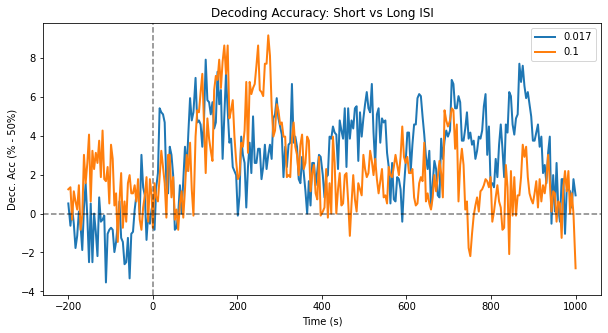

In [19]:
import matplotlib.pyplot as plt

### Normalize 
data_array = np.array(sub_data_expect)
data_array = data_array * 100 - 50# zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1000, n_time).astype(int)

# Split first 4 and last 4 in dims 1,2
first_half = data_array[:, 0:4, 0:4, :]  # shape (4, 4, 4, 301)
last_half = data_array[:, 4:8, 4:8, :]   # shape (4, 4, 4, 301)

# Average across dims 1,2 (image indices)
first_half_avg = np.nanmean(first_half, axis=(1, 2))  # shape (4, 301)
last_half_avg = np.nanmean(last_half, axis=(1, 2))    # shape (4, 301)

# Plot both averaged across subjects
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time, np.nanmean(first_half_avg, axis=0), label='0.017', linewidth=2)
ax.plot(time, np.nanmean(last_half_avg, axis=0), label='0.1', linewidth=2)
ax.axhline(0, linestyle="--", c="k", alpha=0.5)
ax.axvline(0, linestyle="--", c="k", alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Decc. Acc (% - 50%)')
ax.set_title('Decoding Accuracy: Short vs Long ISI')
ax.legend()
plt.show()